In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)
df['Target'] = cali.target
print(df.shape)
df

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1:].values
print(X.shape, y.shape)

(20640, 8) (20640, 1)


In [5]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
X_sc

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

In [6]:
X_tensor = torch.from_numpy(X_sc).float()
y_tensor = torch.from_numpy(y).float()
print(X_tensor.shape, y_tensor.shape)

torch.Size([20640, 8]) torch.Size([20640, 1])


In [7]:
n_epochs = 10000
batch_size = 2048
learning_rate = 1e-4
print_interval = 1000

In [8]:
model = nn.Sequential(
    nn.Linear(X_tensor.shape[-1], 7),
    nn.LeakyReLU(),
    nn.Linear(7, 5),
    nn.LeakyReLU(),
    nn.Linear(5, 3),
    nn.LeakyReLU(),
    nn.Linear(3, y_tensor.shape[-1]),
)
model = model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=7, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=7, out_features=5, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=5, out_features=3, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=3, out_features=1, bias=True)
)


In [9]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
for i in range(n_epochs):
    indices = torch.randperm(X_tensor.shape[0])
    X_ = torch.index_select(X_tensor, dim=0, index=indices).to(device)
    y_ = torch.index_select(y_tensor, dim=0, index=indices).to(device)

    X_ = X_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    y_hat = []
    total_loss = 0

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = F.mse_loss(y_hat_i, y_i)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss.detach())

        y_hat += [y_hat_i]
    
    total_loss = total_loss / len(X_)

    if (i+1) % print_interval == 0:
        print(f'Epoch {i+1}: loss {total_loss:.4f}')

y_hat = torch.concat(y_hat, dim=0)
y = torch.concat(y_, dim=0)

Epoch 1000: loss 0.3752
Epoch 2000: loss 0.3602
Epoch 3000: loss 0.3554
Epoch 4000: loss 0.3359
Epoch 5000: loss 0.3362
Epoch 6000: loss 0.3328
Epoch 7000: loss 0.3418
Epoch 8000: loss 0.3253
Epoch 9000: loss 0.3351
Epoch 10000: loss 0.3301


In [11]:
result_df = pd.DataFrame(torch.concat([y_hat, y], dim=1).cpu().detach_().numpy(), columns=['y_hat', 'y']).clip(lower=0, upper=5)
print(result_df.corr())
result_df

          y_hat         y
y_hat  1.000000  0.869258
y      0.869258  1.000000


,y_hat,y
0,1.354754,1.976
1,1.972661,2.385
2,0.782937,0.867
3,1.285412,0.904
4,1.693176,1.582
...,...,...
20635,1.511502,0.936
20636,1.379311,1.393
20637,2.478248,2.462
20638,1.101625,1.306


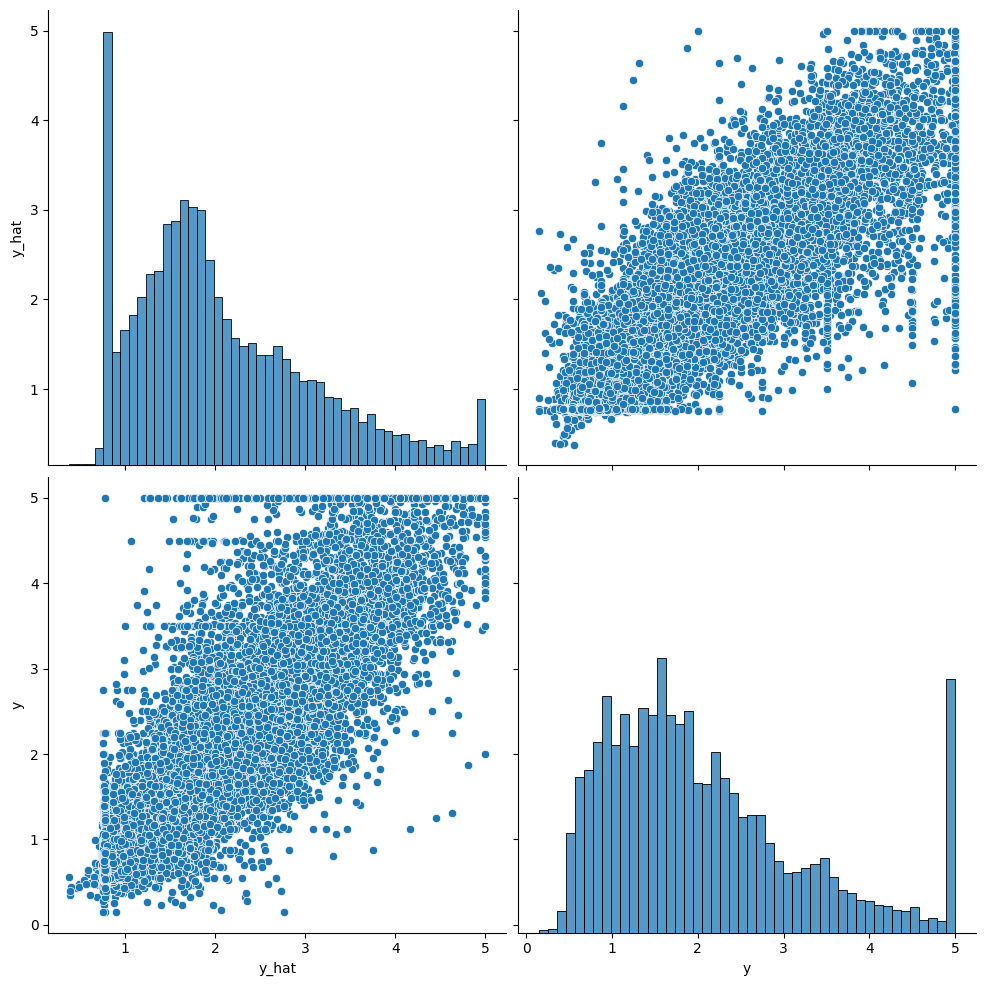

In [12]:
sns.pairplot(result_df, height=5)
plt.show()

In [13]:
del model
torch.cuda.empty_cache()

In [14]:
data = torch.from_numpy(df.values).float()
data.shape

torch.Size([20640, 9])

In [15]:
X = data[:, :-1]
y = data[:, -1:]
scaler = StandardScaler().fit(X)
X_sc = torch.from_numpy(scaler.transform(X).round(4)).float()
X_sc.shape[-1], y.shape[-1]

(8, 1)

In [16]:
model = nn.Sequential(
    nn.Linear(X_sc.shape[-1], 7),
    nn.LeakyReLU(),
    nn.Linear(7, 5),
    nn.LeakyReLU(),
    nn.Linear(5, 3),
    nn.LeakyReLU(),
    nn.Linear(3, y.shape[-1])
)
optimizer = optim.Adam(model.parameters())

In [17]:
for epoch in range(n_epochs):
    indices = torch.randperm(X_sc.shape[0])
    X_ = torch.index_select(X_sc, dim=0, index=indices)
    y_ = torch.index_select(y, dim=0, index=indices)
    X_ = X_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    y_hat = []
    total_loss = 0

    for X_i, y_i in zip(X_, y_):
        y_hat_i = model(X_i)
        loss = F.mse_loss(y_hat_i, y_i)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss.detach())
        y_hat += [y_hat_i]
    
    total_loss = total_loss / len(X_)

    if (epoch + 1) % print_interval == 0:
        print(f'Epoch {epoch + 1}: loss {total_loss:.4f}')

y_hat = torch.concat(y_hat, dim=0)
y = torch.concat(y_, dim=0)

Epoch 1000: loss 0.3063
Epoch 2000: loss 0.2833
Epoch 3000: loss 0.2889
Epoch 4000: loss 0.2870
Epoch 5000: loss 0.2796
Epoch 6000: loss 0.2784
Epoch 7000: loss 0.2849
Epoch 8000: loss 0.2786
Epoch 9000: loss 0.2840
Epoch 10000: loss 0.2795


In [18]:
result_df = pd.DataFrame(torch.concat([y_hat, y], dim=1).cpu().detach_().numpy(), columns=['y_hat', 'y']).clip(lower=0, upper=5)
print(result_df.corr())
result_df

          y_hat         y
y_hat  1.000000  0.889734
y      0.889734  1.000000


,y_hat,y
0,2.571041,4.750
1,2.807916,2.210
2,1.766735,2.182
3,1.505795,1.550
4,2.687062,2.490
...,...,...
20635,1.868440,2.063
20636,1.912492,1.365
20637,2.879923,2.659
20638,2.353384,2.296


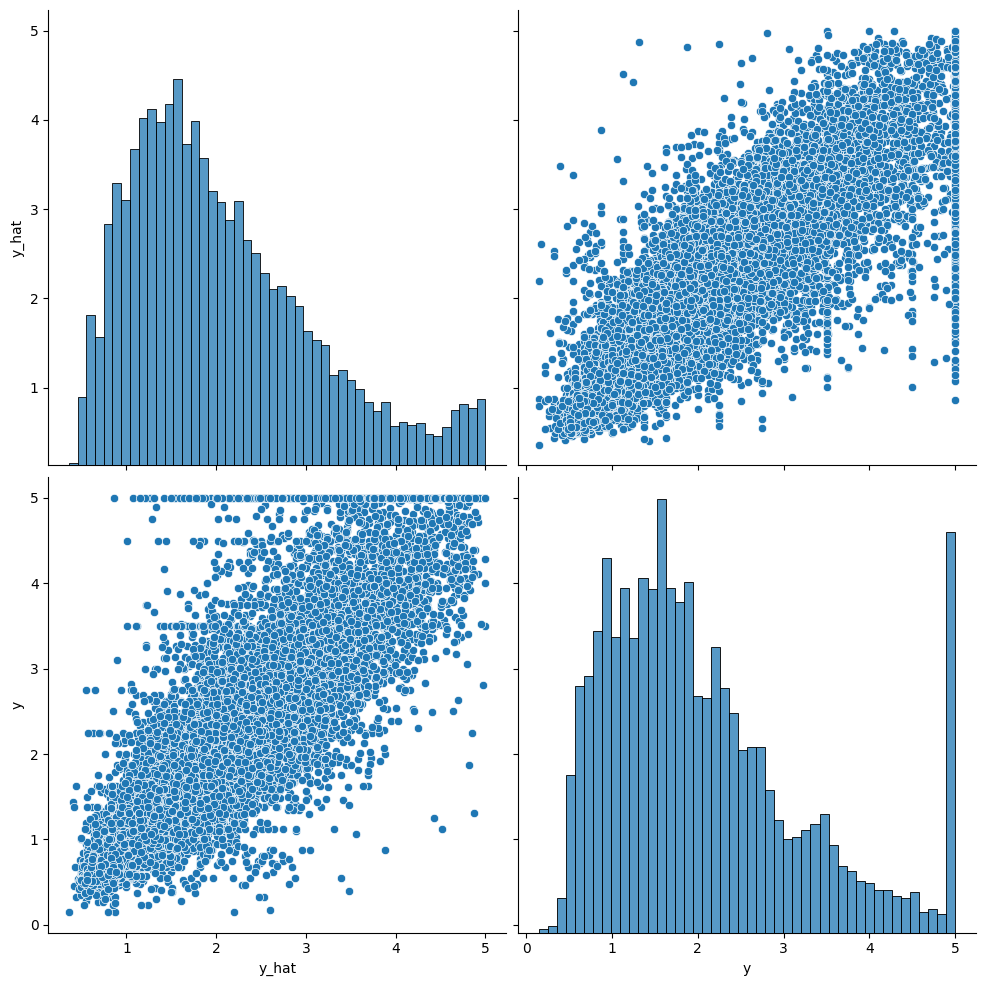

In [19]:
sns.pairplot(result_df, height=5)
plt.show()

In [20]:
del model
torch.cuda.empty_cache()